# 03 Entrenamiento y comparacion de modelos

Este notebook toma el rol de `experiments.ipynb` del repo de referencia, pero aplicado a series mensuales de productos. Aqui se entrenan exclusivamente modelos de Machine Learning.

Modelos evaluados:

- `hist_gradient_boosting`: modelo principal.
- `hist_gradient_boosting_tuned`: Gradient Boosting con tuning de hiperparametros.
- `random_forest`: bosque aleatorio no lineal.
- `random_forest_conservative`: bosque aleatorio mas regularizado para reducir sobreajuste.
- `extra_trees`: ensamble de arboles extremadamente aleatorizados.
- `linear_regression`: regresion lineal.
- `ridge_regression`: regresion lineal regularizada.
- `sgd_gradient_regression`: regresion lineal ajustada con descenso por gradiente.
La metrica principal para comparar es WAPE: error absoluto total dividido para volumen real total.

La seleccion final usa `forecast_model: best_ml_stable`, que escoge el modelo ML con mejor balance entre validacion y test historico.

Si se completan las plantillas de variables exogenas, esas columnas entran como features adicionales del modelo.

In [2]:
from pathlib import Path
import sys
from io import StringIO

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

def find_project_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "config" / "config.yml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("No se encontro la raiz del proyecto. Abre VS Code en la carpeta 'Avance 3'.")

ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "src"))

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)
plt.style.use("default")

from quickbooks_forecast.config import load_config

config = load_config()
reports_dir = config["resolved_paths"]["reports_dir"]
processed_dir = config["resolved_paths"]["processed_dir"]
raw_dir = config["resolved_paths"]["raw_dir"]
images_dir = ROOT / "notebooks" / "images"
images_dir.mkdir(parents=True, exist_ok=True)

def save_fig(name, extension="png", resolution=160):
    path_final = images_dir / f"{name}.{extension}"
    plt.tight_layout()
    plt.savefig(path_final, dpi=resolution, bbox_inches="tight")
    print(f"Figura guardada: {path_final}")

**Preparacion del entrenamiento:**

Este bloque prepara el entorno de entrenamiento. Desde aqui se usan los datasets limpios y las mismas configuraciones del pipeline automatizado.

In [3]:
from quickbooks_forecast.modeling import train_all

artifacts = train_all(config)
print("Modelos entrenados:", list(artifacts))

Modelos entrenados: ['PT', 'PP']


**Entrenamiento de modelos ML:**

Se entrenan modelos separados para PT y PP. Todos los candidatos son modelos de Machine Learning; los promedios moviles o reglas simples no se usan como modelo final.

In [4]:
comparison = pd.read_csv(reports_dir / "model_comparison_all.csv")
validation = pd.read_csv(reports_dir / "validation_model_comparison_all.csv")
tuning = pd.read_csv(reports_dir / "hgb_tuning_all.csv")

print("Comparacion en validacion")
display(validation.sort_values(["source", "rank_wape"]))
print("Comparacion en test")
display(comparison.sort_values(["source", "rank_wape"]))
print("Mejores hiperparametros HGB por tipo")
display(tuning.sort_values(["source", "rank_validation"]).groupby("source").head(1))

Comparacion en validacion


,mae,rmse,smape,wape,source,model_name,split,rows,period_from,period_until,selected_for_forecast,rank_wape
8,621.266491,4225.989946,0.036038,0.077259,PP,random_forest,validation,694,2025-09-01,2025-11-01,True,1
9,708.997145,4150.701812,0.448168,0.088168,PP,hist_gradient_boosting_tuned,validation,694,2025-09-01,2025-11-01,False,2
10,767.375979,5911.313274,0.449817,0.095428,PP,extra_trees,validation,694,2025-09-01,2025-11-01,False,3
11,806.093734,6765.654739,0.044739,0.100243,PP,random_forest_conservative,validation,694,2025-09-01,2025-11-01,False,4
12,950.268445,6677.326602,0.392380,0.118172,PP,hist_gradient_boosting,validation,694,2025-09-01,2025-11-01,False,5
13,8478.868411,39888.587309,1.360818,1.054403,PP,sgd_gradient_regression,validation,694,2025-09-01,2025-11-01,False,6
14,8971.996026,43129.465391,1.349127,1.115727,PP,ridge_regression,validation,694,2025-09-01,2025-11-01,False,7
15,10054.296526,48001.558683,1.367153,1.250318,PP,linear_regression,validation,694,2025-09-01,2025-11-01,False,8
0,277.201492,1162.451242,0.047799,0.071866,PT,random_forest,validation,2619,2025-10-01,2025-12-01,True,1
1,289.943202,1241.543197,0.048472,0.075170,PT,random_forest_conservative,validation,2619,2025-10-01,2025-12-01,False,2


Comparacion en test


,mae,rmse,smape,wape,source,model_name,split,rows,period_from,period_until,selected_for_forecast,rank_wape
8,381.752838,1328.726245,0.553460,0.056561,PP,extra_trees,test,712,2025-12-01,2026-02-01,False,1
9,392.274896,1445.168079,0.030516,0.058120,PP,random_forest,test,712,2025-12-01,2026-02-01,True,2
10,455.147890,1789.839723,0.034964,0.067435,PP,random_forest_conservative,test,712,2025-12-01,2026-02-01,False,3
11,533.337603,3489.325306,0.509031,0.079020,PP,hist_gradient_boosting,test,712,2025-12-01,2026-02-01,False,4
12,534.872573,2278.153233,0.253821,0.079247,PP,hist_gradient_boosting_tuned,test,712,2025-12-01,2026-02-01,False,5
13,6308.834913,23881.995215,1.365669,0.934722,PP,linear_regression,test,712,2025-12-01,2026-02-01,False,6
14,7202.976202,40061.727079,1.374319,1.067198,PP,ridge_regression,test,712,2025-12-01,2026-02-01,False,7
15,7353.266309,40418.358037,1.361532,1.089465,PP,sgd_gradient_regression,test,712,2025-12-01,2026-02-01,False,8
0,165.923796,531.828157,0.039381,0.057792,PT,random_forest,test,2663,2026-01-01,2026-03-01,True,1
1,173.220985,706.577091,0.040234,0.060333,PT,random_forest_conservative,test,2663,2026-01-01,2026-03-01,False,2


Mejores hiperparametros HGB por tipo


,source,candidate,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,mae,rmse,smape,wape,rows_train,rows_validation,rank_validation
7,PP,7,0.03,500,31,10,0.00,708.997145,4150.701812,0.448168,0.088168,2672,694,1
0,PT,6,0.05,400,63,20,0.05,328.845066,1828.623508,0.439362,0.085255,23452,2619,1


**Seleccion por validacion temporal:**

Esta comparacion justifica el criterio de seleccion. El modelo elegido no se escoge a mano: se compara por WAPE en validacion temporal y test historico.

Figura guardada: F:\proyecto-integrador\Avance 3\03_modelado\forecasting_v3\notebooks\images\03_comparacion_modelos_wape.png


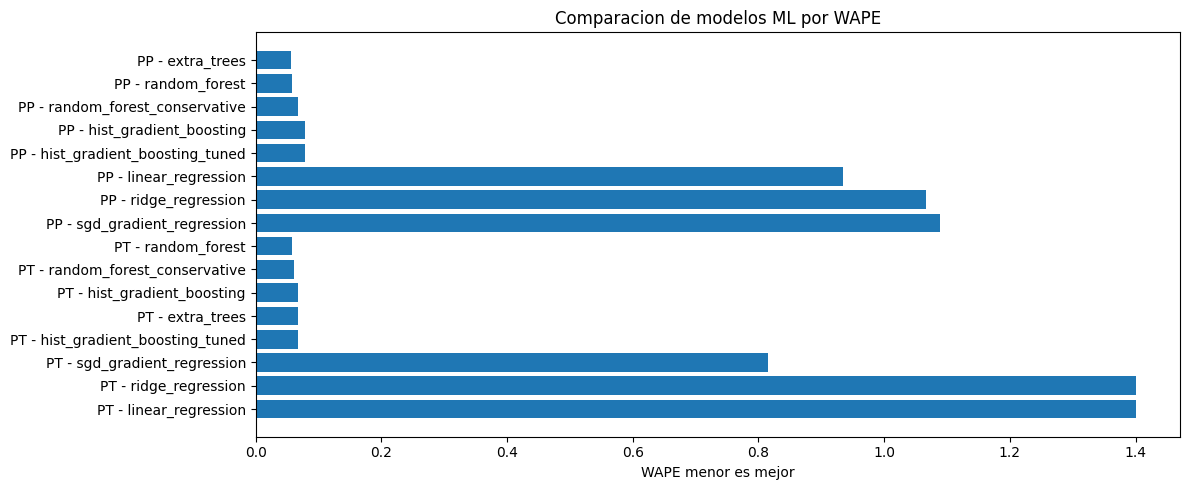

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_data = comparison.sort_values(["source", "wape"]).copy()
labels = plot_data["source"] + " - " + plot_data["model_name"]
ax.barh(labels, plot_data["wape"])
ax.set_title("Comparacion de modelos ML por WAPE")
ax.set_xlabel("WAPE menor es mejor")
ax.invert_yaxis()
save_fig("03_comparacion_modelos_wape")
plt.show()

**Comparacion visual de modelos:**

La grafica facilita explicar que modelos no lineales, especialmente Random Forest, capturan mejor patrones de producto, temporada y variables exogenas.

In [6]:
metrics_pt = pd.read_csv(reports_dir / "metrics_pt.csv")
metrics_pp = pd.read_csv(reports_dir / "metrics_pp.csv")

print("Metricas modelo principal PT")
display(metrics_pt)
print("Metricas modelo principal PP")
display(metrics_pp)

Metricas modelo principal PT


,mae,rmse,smape,wape,source,selected_model_name,selection_metric,train_rows,validation_rows,test_rows,train_until,validation_from,validation_until,test_from,test_until
0,165.923796,531.828157,0.039381,0.057792,PT,random_forest,wape,26071,2619,2663,2025-12-01,2025-10-01,2025-12-01,2026-01-01,2026-03-01


Metricas modelo principal PP


,mae,rmse,smape,wape,source,selected_model_name,selection_metric,train_rows,validation_rows,test_rows,train_until,validation_from,validation_until,test_from,test_until
0,392.274896,1445.168079,0.030516,0.05812,PP,random_forest,wape,3366,694,712,2025-11-01,2025-09-01,2025-11-01,2025-12-01,2026-02-01


**Metricas finales del modelo:**

Estas son las metricas principales para la presentacion. Con el escenario `replacement`, PT y PP quedan cerca del rango 5%-7% WAPE requerido para evaluar reemplazo asistido de la planificacion humana.

In [7]:
high_error = pd.read_csv(reports_dir / "high_error_products_all.csv")
display(
    high_error[
        [
            "source_type",
            "product_id",
            "product_name",
            "cantidad_real_total",
            "cantidad_predicha_total",
            "error_absoluto_total",
            "wape_producto",
            "prioridad_revision",
        ]
    ].head(40)
)

,source_type,product_id,product_name,cantidad_real_total,cantidad_predicha_total,error_absoluto_total,wape_producto,prioridad_revision
0,PT,PT_4841,EL ARTESANAL ACEITE GIRASOL 1L (4841),213892.0,220448.752820,19309.518052,0.090277,alta
1,PT,PT_3058,EL ARTESANAL ACEITE VEGETAL 1L (3058),200707.0,187944.624000,12762.376000,0.063587,alta
2,PT,PT_4715,* EL ARTESANAL ACEITE OLIVA EXTRA VIRGEN 250 M...,131273.0,120986.003230,10286.996770,0.078363,alta
3,PT,PT_0077,CANELA RAMA FDA 30 GRS(0077),136847.0,132539.325812,9710.234852,0.070957,alta
4,PT,PT_8608,* ALINO BOT 310 GRS. (8608),131947.0,137223.427802,9381.147454,0.071098,alta
...,...,...,...,...,...,...,...,...
35,PT,PT_1616,COMINO MOLIDO FDA 50 GRS. (1616),54190.0,56777.772192,2587.772192,0.047754,alta
36,PT,PT_4838,EL ARTESANAL PIMIENTA MOLIDA FUNDA 50 GR (4838),35466.0,37436.616786,2500.693289,0.070510,alta
37,PT,PT_8054,*EL ARTESANAL CHIFLE DULCE 30G (8054)..,61962.0,63335.173488,2496.631723,0.040293,alta
38,PT,PT_5888,LA ORIGINAL AJO POLVO FDA 50G(5888),32012.0,33260.949153,2431.407818,0.075953,alta


**Priorizacion de productos con error:**

Esta tabla convierte el error en accion operativa: identifica productos que no deben automatizarse sin revision de produccion o comercial.

In [8]:
backtest_pt = pd.read_csv(reports_dir / "backtest_pt.csv", parse_dates=["periodo"])
backtest_pp = pd.read_csv(reports_dir / "backtest_pp.csv", parse_dates=["periodo"])

print("Backtest PT")
display(backtest_pt.head())
print("Backtest PP")
display(backtest_pp.head())

Backtest PT


,source_type,product_id,product_name,periodo,target_qty,estado_producto,es_estacional,meses_estacionales,prediction_extra_trees,abs_error_extra_trees,prediction_hist_gradient_boosting,abs_error_hist_gradient_boosting,prediction_hist_gradient_boosting_tuned,abs_error_hist_gradient_boosting_tuned,prediction_linear_regression,abs_error_linear_regression,prediction_random_forest,abs_error_random_forest,prediction_random_forest_conservative,abs_error_random_forest_conservative,prediction_ridge_regression,abs_error_ridge_regression,prediction_sgd_gradient_regression,abs_error_sgd_gradient_regression
0,PT,PT_0000,SAZONADOR AZAFRAN KILO (0000),2026-01-01,20.0,activo,False,"enero, octubre, julio",22.047933,2.047933,20.559018,0.559018,20.768956,0.768956,7.798705,12.201295,22.230956,2.230956,22.552900,2.552900,7.792462,12.207538,11.214431,8.785569
1,PT,PT_0000,SAZONADOR AZAFRAN KILO (0000),2026-02-01,0.0,activo,False,"enero, octubre, julio",0.002571,0.002571,0.003269,0.003269,0.002440,0.002440,9.971079,9.971079,0.000000,0.000000,0.000000,0.000000,9.978737,9.978737,18.984524,18.984524
2,PT,PT_0000,SAZONADOR AZAFRAN KILO (0000),2026-03-01,8.0,activo,False,"enero, octubre, julio",7.610295,0.389705,8.549810,0.549810,8.280305,0.280305,20.725319,12.725319,7.507951,0.492049,7.529253,0.470747,21.350811,13.350811,31.626228,23.626228
3,PT,PT_0015,MANI PAST FDA 200 GRS(0015),2026-01-01,1396.0,activo,False,"marzo, febrero, abril",1300.023025,95.976975,1338.085599,57.914401,1333.537322,62.462678,1796.520661,400.520661,1398.711826,2.711826,1405.044785,9.044785,1797.729264,401.729264,1797.271454,401.271454
4,PT,PT_0015,MANI PAST FDA 200 GRS(0015),2026-02-01,2604.0,activo,False,"marzo, febrero, abril",2996.265302,392.265302,3010.833520,406.833520,3005.863339,401.863339,2952.446143,348.446143,2888.010993,284.010993,2950.631980,346.631980,2918.680306,314.680306,2634.805146,30.805146


Backtest PP


,source_type,product_id,product_name,periodo,target_qty,estado_producto,es_estacional,meses_estacionales,prediction_extra_trees,abs_error_extra_trees,prediction_hist_gradient_boosting,abs_error_hist_gradient_boosting,prediction_hist_gradient_boosting_tuned,abs_error_hist_gradient_boosting_tuned,prediction_linear_regression,abs_error_linear_regression,prediction_random_forest,abs_error_random_forest,prediction_random_forest_conservative,abs_error_random_forest_conservative,prediction_ridge_regression,abs_error_ridge_regression,prediction_sgd_gradient_regression,abs_error_sgd_gradient_regression
0,PP,PP_01396889e6,MOSTAZA PRODUCCIÓN GRANEL,2025-12-01,9727.52,activo,False,"enero, septiembre, agosto",9466.836564,260.683436,9417.844866,309.675134,9248.074513,479.445487,132.811261,9594.708739,9534.469613,193.050387,9500.580241,226.939759,126.040263,9601.479737,118.281908,9609.238092
1,PP,PP_01396889e6,MOSTAZA PRODUCCIÓN GRANEL,2026-01-01,8138.59,activo,False,"enero, septiembre, agosto",7586.118781,552.471219,7697.229603,441.360397,7538.447941,600.142059,896.069226,7242.520774,7663.020284,475.569716,7777.987780,360.602220,873.437955,7265.152045,1000.291235,7138.298765
2,PP,PP_01396889e6,MOSTAZA PRODUCCIÓN GRANEL,2026-02-01,4851.96,activo,False,"enero, septiembre, agosto",5021.224042,169.264042,5117.222859,265.262859,5082.076365,230.116365,71.495861,4780.464139,5125.828909,273.868909,5238.886721,386.926721,71.816949,4780.143051,91.107439,4760.852561
3,PP,PP_021ba1ac93,* ALINO COMPLETO KILOS GRANEL,2025-12-01,0.00,activo,True,"octubre, noviembre, febrero",0.018310,0.018310,0.000000,0.000000,0.008133,0.008133,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.957887,3.957887,0.000000,0.000000
4,PP,PP_021ba1ac93,* ALINO COMPLETO KILOS GRANEL,2026-01-01,93676.00,activo,True,"octubre, noviembre, febrero",98859.348717,5183.348717,113309.713134,19633.713134,106201.509747,12525.509747,71.682465,93604.317535,96871.399359,3195.399359,96219.141563,2543.141563,2305.983347,91370.016653,7485.163128,86190.836872


**Backtest historico producto-mes:**

El backtest muestra prediccion contra valor real en meses historicos no usados como entrenamiento final. Esto permite defender que la evaluacion respeta el tiempo.

Figura guardada: F:\proyecto-integrador\Avance 3\03_modelado\forecasting_v3\notebooks\images\03_productos_mayor_error.png


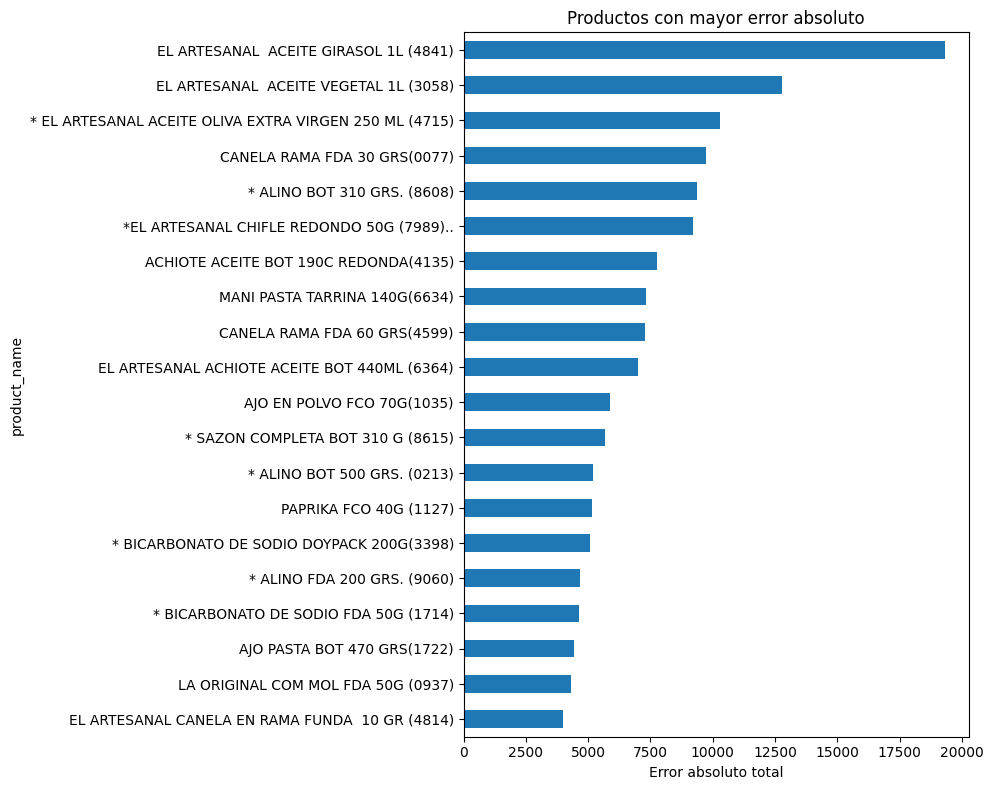

In [9]:
high_error.head(20).plot(
    kind="barh",
    x="product_name",
    y="error_absoluto_total",
    figsize=(10, 8),
    legend=False,
    title="Productos con mayor error absoluto",
)
plt.xlabel("Error absoluto total")
plt.gca().invert_yaxis()
save_fig("03_productos_mayor_error")
plt.show()

**Riesgo concentrado por producto:**

Los productos con mayor error absoluto concentran el riesgo de decision. Para automatizar, estos casos deben quedar marcados como revision obligatoria.

Lectura sugerida:

- El modelo seleccionado debe ser ML; los metodos estadisticos simples no se usan como candidato final.
- Si regresion lineal o SGD tienen errores altos, se descartan frente a modelos ML no lineales.
- Si Gradient Boosting tuneado no mejora, se comparan Random Forest y Extra Trees como alternativas ML no lineales.
- La seleccion final conserva el ML mas estable por validacion/test.
- Para bajar el error de forma fuerte, completar variables exogenas historicas y futuras conocidas antes del mes.
- El modo `--replacement-demo` del generador de exogenas sirve como escenario asistido: simula que pedidos/preventas/ajustes contienen una propuesta humana conocida antes del mes y debe reemplazarse por datos reales para una validacion oficial.
- Los productos de mayor error deben validarse con produccion/comercial antes de tomar decisiones.